In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import sys
sys.path.append(r'\\192.168.10.106\imdea\DataDriven_UT_AlbertoVicente\10_code\UTvsXCT-preprocessing')
sys.path.append(r'/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/10_code/UTvsXCT-preprocessing')

from preprocess_tools import aligner,onlypores,io,pore_filtering,reslicer

In [2]:
#load the onlypores to filter

file_path = Path(r"/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/02_XCT_data/Fabricacion Nacho/05_Probetas_Nacho_2025/probetas/Na_01_1/volume_eq_aligned.tif")

volume = io.load_tif(file_path)

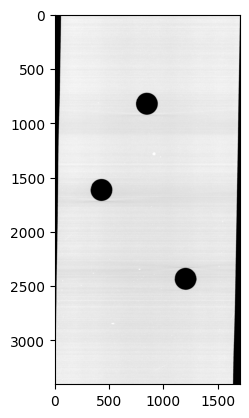

In [3]:
plt.imshow(volume.max(axis=0), cmap='gray')

In [4]:
volume  = reslicer.rotate_90(volume,False)
volume = reslicer.reslice(volume,'Right')

#get the frontwall and backwall of the xct volume
_,frontwall,backwall = aligner.crop_walls(volume)

volume = reslicer.reslice(volume,'Left')
volume  = reslicer.rotate_90(volume,True)

print(frontwall, backwall)

Computing material mask using sequential processing...
Filling internal voids...
Material mask generation complete.
8 193


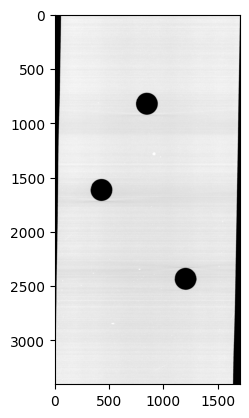

In [5]:
plt.imshow(volume.max(axis=0), cmap='gray')

In [6]:
onlypores_volume,sample_mask,binary = onlypores.onlypores(volume,frontwall=frontwall, backwall=backwall, min_size_filtering=0)

Starting pore detection analysis...
Computing volume bounding box...
Original volume shape: (208, 3405, 1703)
Data bounding box: Z[0:207], Y[0:3404], X[0:1702]
Cropped volume shape: (208, 3405, 1703)
Applying Sauvola adaptive thresholding...
Volume size: 1.12 GB
Available memory: 199.54 GB
Required memory estimate: 2.25 GB
Using parallel implementation...
Window size adjusted to 31 (must be odd)
Applying Sauvola thresholding with parallel processing...
Excluding front wall: slices 0 to 7
Excluding back wall: slices 193 to end
Generating material mask...
Computing material mask using sequential processing...
Filling internal voids...
Material mask generation complete.
Initial pore detection complete. Found 23835959 pore voxels.
Pore detection analysis complete.


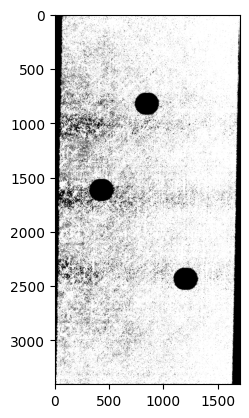

In [7]:
plt.imshow(onlypores_volume.max(axis=0), cmap='gray')

# Feautres extraction

In [8]:
#label onlypores volume
from skimage import measure
labeled_pores = measure.label(onlypores_volume, connectivity=3)

In [9]:
def compute_pore_features(labeled_volume):
    """
    Compute flatness and cenital orientation for each labeled object in a volume.
    
    Parameters:
    -----------
    labeled_volume : ndarray
        3D array with labeled objects (background = 0, objects = 1, 2, 3, ...)
    
    Returns:
    --------
    features : dict
        Dictionary with keys 'label', 'flatness', 'cenital_orientation'
        - label: list of object labels
        - flatness: ratio between smallest and largest eigenvalue
        - cenital_orientation: angle (in degrees) between largest eigenvector and Z axis
    """
    from skimage import measure
    import numpy as np
    
    # Get region properties
    regions = measure.regionprops(labeled_volume)
    
    labels = []
    flatness_values = []
    cenital_orientations = []
    
    for region in regions:
        # Skip very small regions (fewer than 4 voxels needed for 3D covariance)
        if region.area < 4:
            continue
            
        # Get the coordinates of all voxels in this region
        coords = region.coords  # Shape: (n_voxels, 3) with columns [z, y, x]
        
        # Center the coordinates
        centered_coords = coords - coords.mean(axis=0)
        
        # Compute covariance matrix
        cov_matrix = np.cov(centered_coords.T)
        
        try:
            # Compute eigenvalues and eigenvectors
            eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        except np.linalg.LinAlgError:
            # Skip regions where eigenvalue computation fails
            print(f"Warning: Skipping region {region.label} - eigenvalue computation failed")
            continue
        
        # Sort by eigenvalue magnitude (ascending order)
        sorted_indices = np.argsort(eigenvalues)
        eigenvalues = eigenvalues[sorted_indices]
        eigenvectors = eigenvectors[:, sorted_indices]
        
        # Flatness: ratio between smallest and largest eigenvalue
        if eigenvalues[1] > 1e-10:  # Use small threshold instead of zero
            flatness = eigenvalues[0] / eigenvalues[1]
        else:
            # Degenerate case: all points at same location
            continue
        
        # Cenital orientation: angle between largest eigenvector and Z axis
        # Z axis is [1, 0, 0] in the coordinate system (z, y, x)
        z_axis = np.array([1, 0, 0])
        largest_eigenvector = eigenvectors[:, -1]  # Eigenvector corresponding to largest eigenvalue
        
        # Compute angle using dot product
        cos_angle = np.abs(np.dot(largest_eigenvector, z_axis))  # Use abs to get acute angle
        cos_angle = np.clip(cos_angle, -1, 1)  # Ensure valid range for arccos
        angle_rad = np.arccos(cos_angle)
        angle_deg = np.degrees(angle_rad)
        
        labels.append(region.label)
        flatness_values.append(flatness)
        cenital_orientations.append(angle_deg)
    
    return {
        'label': labels,
        'flatness': np.array(flatness_values),
        'cenital_orientation': np.array(cenital_orientations)
    }

In [10]:
# Enhanced Professional Plot Theme Configuration
# Color palette: #4281a4 (primary blue), #4c3b4d (deep purple), #48a9a6 (teal), #e4dfda (light beige), #e980fc (magenta)

def apply_plot_theme():
    """Apply the enhanced professional plot theme to current figure"""
    fig = plt.gcf()
    ax = plt.gca()
    
    # Set figure size and colors
    fig.set_size_inches(10, 6)
    fig.patch.set_facecolor('#f8f6f4')  # Slightly warmer white background
    ax.set_facecolor('#fdfcfb')  # Very light warm background for plot area
    
    # Configure enhanced grid
    ax.grid(True, axis='y', alpha=0.4, color='#e4dfda', linewidth=0.8, linestyle='-')
    ax.grid(True, axis='x', alpha=0.2, color='#e4dfda', linewidth=0.5, linestyle=':')
    ax.set_axisbelow(True)
    
    # Enhanced text styling with better contrast
    ax.tick_params(colors='#4c3b4d', labelsize=11, width=1.2)  # Deep purple tick labels
    ax.xaxis.label.set_color('#4c3b4d')  # Deep purple for better readability
    ax.yaxis.label.set_color('#4c3b4d')  # Deep purple for better readability
    ax.xaxis.label.set_fontsize(13)
    ax.yaxis.label.set_fontsize(13)
    ax.xaxis.label.set_fontweight('medium')
    ax.yaxis.label.set_fontweight('medium')
    
    # Enhanced spine styling
    for spine in ax.spines.values():
        spine.set_color('#4c3b4d')
        spine.set_linewidth(1.3)
        spine.set_alpha(0.8)
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Enhanced legend styling
    legend = ax.get_legend()
    if legend:
        legend.get_frame().set_facecolor('#fdfcfb')
        legend.get_frame().set_edgecolor('#4c3b4d')
        legend.get_frame().set_linewidth(1.2)
        legend.get_frame().set_alpha(0.95)
        for text in legend.get_texts():
            text.set_color('#4c3b4d')
            text.set_fontsize(11)
            text.set_fontweight('medium')
        # Add subtle shadow to legend
        legend.get_frame().set_boxstyle("round,pad=0.5")
    
    # Enhanced layout with better spacing
    plt.tight_layout(pad=2.5)
    
    # Subtle border around the entire plot
    fig.patch.set_linewidth(1)
    fig.patch.set_edgecolor('#e4dfda')

In [11]:
# Compute features for all labeled pores
features = compute_pore_features(labeled_pores)

# Display results
print(f"Number of pores analyzed: {len(features['label'])}")
print(f"\nFlatness statistics:")
print(f"  Mean: {features['flatness'].mean():.4f}")
print(f"  Std: {features['flatness'].std():.4f}")
print(f"  Min: {features['flatness'].min():.4f}")
print(f"  Max: {features['flatness'].max():.4f}")
print(f"\nCenital orientation statistics (degrees):")
print(f"  Mean: {features['cenital_orientation'].mean():.2f}")
print(f"  Std: {features['cenital_orientation'].std():.2f}")
print(f"  Min: {features['cenital_orientation'].min():.2f}")
print(f"  Max: {features['cenital_orientation'].max():.2f}")

Number of pores analyzed: 403906

Flatness statistics:
  Mean: 0.3079
  Std: 0.2335
  Min: -0.0000
  Max: 1.0000

Cenital orientation statistics (degrees):
  Mean: 76.96
  Std: 15.09
  Min: 0.00
  Max: 90.00


In [12]:
figures_folder = Path(r'/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/00_literature/05_Alberto_Vicente/01_FYA/First_Year/Figures')

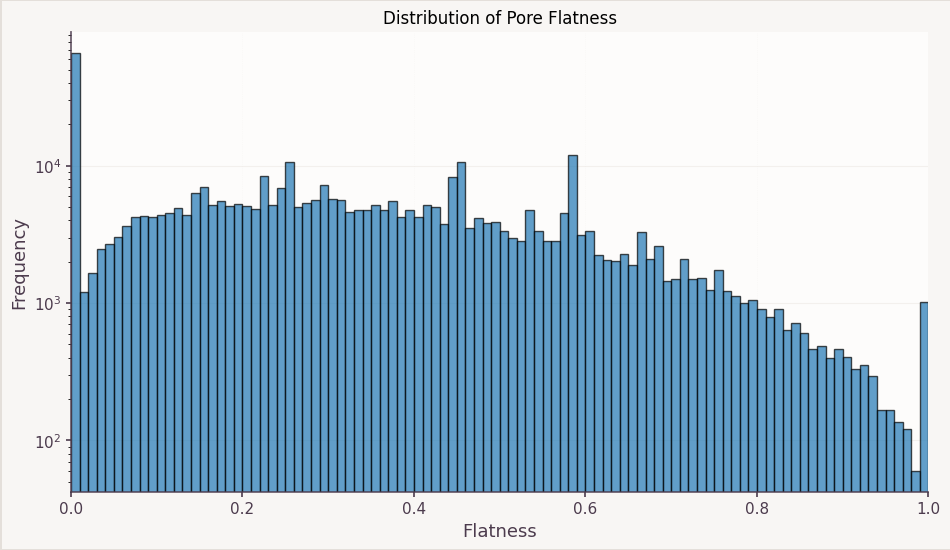

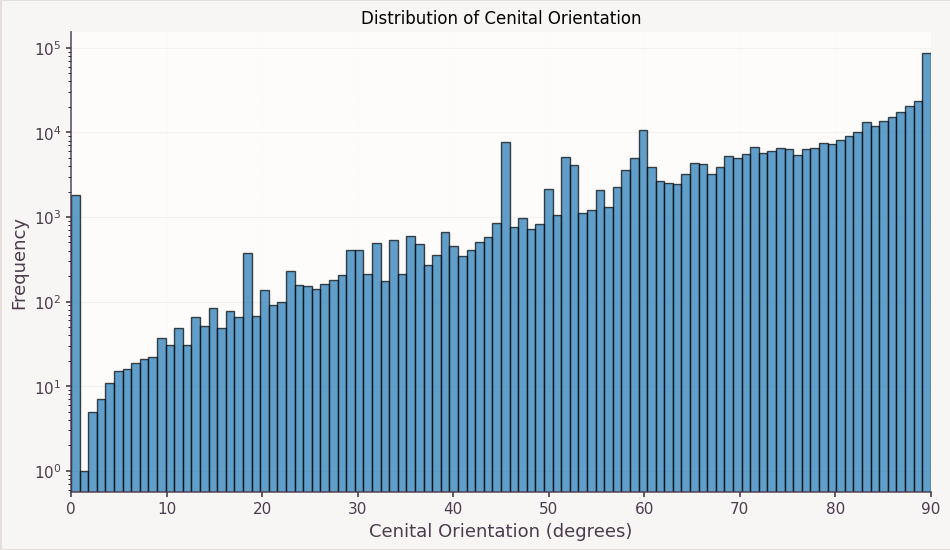

In [13]:
# Flatness histogram (Figure 1)
fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.hist(features['flatness'], bins=np.linspace(0, 1, 101), edgecolor='black', alpha=0.7)
ax1.set_xlabel('Flatness')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Pore Flatness')
ax1.set_xlim(0, 1)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
apply_plot_theme()
fig1.savefig(figures_folder / 'pore_flatness_distribution.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Cenital orientation histogram (Figure 2)
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(features['cenital_orientation'], bins=np.linspace(0, 90, 101), edgecolor='black', alpha=0.7)
ax2.set_xlabel('Cenital Orientation (degrees)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Cenital Orientation')
ax2.set_xlim(0, 90)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
apply_plot_theme()

fig2.savefig(figures_folder / 'pore_cenital_orientation_distribution.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Filtering

In [14]:
# import remove small objects
from skimage.morphology import remove_small_objects

print(len(np.unique(labeled_pores)))

onlypores_8 = remove_small_objects(labeled_pores, max_size=8)

print(len(np.unique(onlypores_8)))

1415942
229052


In [15]:
# Compute features for all labeled pores
features_8 = compute_pore_features(onlypores_8)

# Display results
print(f"Number of pores analyzed: {len(features_8['label'])}")
print(f"\nFlatness statistics:")
print(f"  Mean: {features_8['flatness'].mean():.4f}")
print(f"  Std: {features_8['flatness'].std():.4f}")
print(f"  Min: {features_8['flatness'].min():.4f}")
print(f"  Max: {features_8['flatness'].max():.4f}")
print(f"\nCenital orientation statistics (degrees):")
print(f"  Mean: {features_8['cenital_orientation'].mean():.2f}")
print(f"  Std: {features_8['cenital_orientation'].std():.2f}")
print(f"  Min: {features_8['cenital_orientation'].min():.2f}")
print(f"  Max: {features_8['cenital_orientation'].max():.2f}")

Number of pores analyzed: 229049

Flatness statistics:
  Mean: 0.3578
  Std: 0.2162
  Min: -0.0000
  Max: 1.0000

Cenital orientation statistics (degrees):
  Mean: 80.64
  Std: 11.12
  Min: 0.00
  Max: 90.00


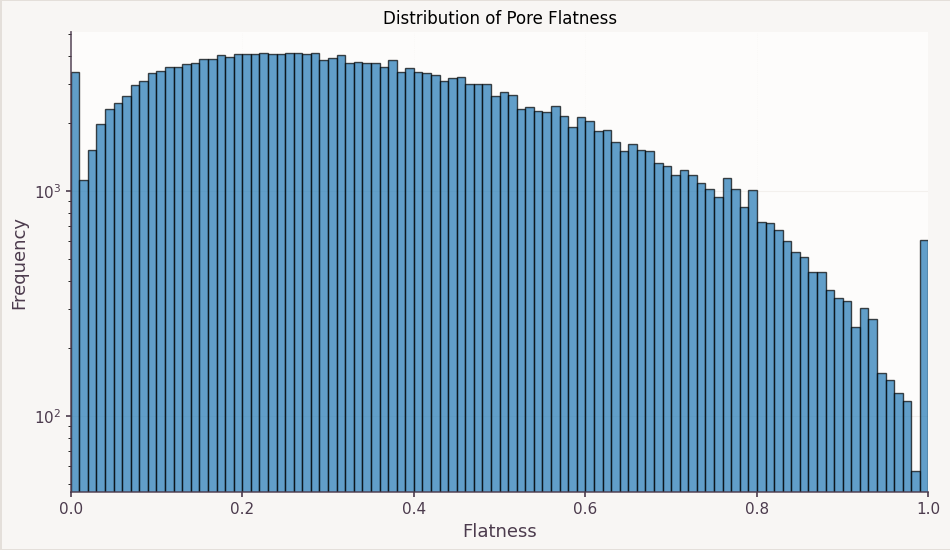

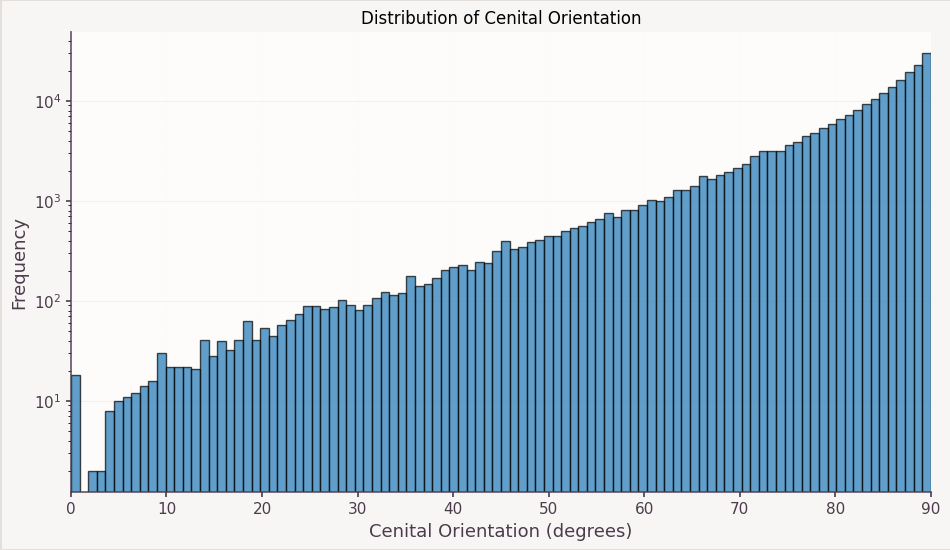

In [16]:
# Visualize the feature distributions in separate figures
fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.hist(features_8['flatness'], bins=np.linspace(0, 1, 101), edgecolor='black', alpha=0.7)
ax1.set_xlabel('Flatness')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Pore Flatness')
ax1.set_xlim(0, 1)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
apply_plot_theme()
fig1.savefig(figures_folder / 'pore_flatness_distribution_filtered_8.pdf', bbox_inches='tight', dpi=300)
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(features_8['cenital_orientation'], bins=np.linspace(0, 90, 101), edgecolor='black', alpha=0.7)
ax2.set_xlabel('Cenital Orientation (degrees)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Cenital Orientation')
ax2.set_xlim(0, 90)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
apply_plot_theme()

fig2.savefig(figures_folder / 'pore_cenital_orientation_distribution_filtered_8.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [17]:
# import remove small objects
from skimage.morphology import remove_small_objects

onlypores_16 = remove_small_objects(labeled_pores, max_size=16)

In [18]:
# Compute features for all labeled pores
features_16 = compute_pore_features(onlypores_16)

# Display results
print(f"Number of pores analyzed: {len(features_16['label'])}")
print(f"\nFlatness statistics:")
print(f"  Mean: {features_16['flatness'].mean():.4f}")
print(f"  Std: {features_16['flatness'].std():.4f}")
print(f"  Min: {features_16['flatness'].min():.4f}")
print(f"  Max: {features_16['flatness'].max():.4f}")
print(f"\nCenital orientation statistics (degrees):")
print(f"  Mean: {features_16['cenital_orientation'].mean():.2f}")
print(f"  Std: {features_16['cenital_orientation'].std():.2f}")
print(f"  Min: {features_16['cenital_orientation'].min():.2f}")
print(f"  Max: {features_16['cenital_orientation'].max():.2f}")

Number of pores analyzed: 157762

Flatness statistics:
  Mean: 0.3343
  Std: 0.2084
  Min: -0.0000
  Max: 1.0000

Cenital orientation statistics (degrees):
  Mean: 82.67
  Std: 9.28
  Min: 0.00
  Max: 90.00


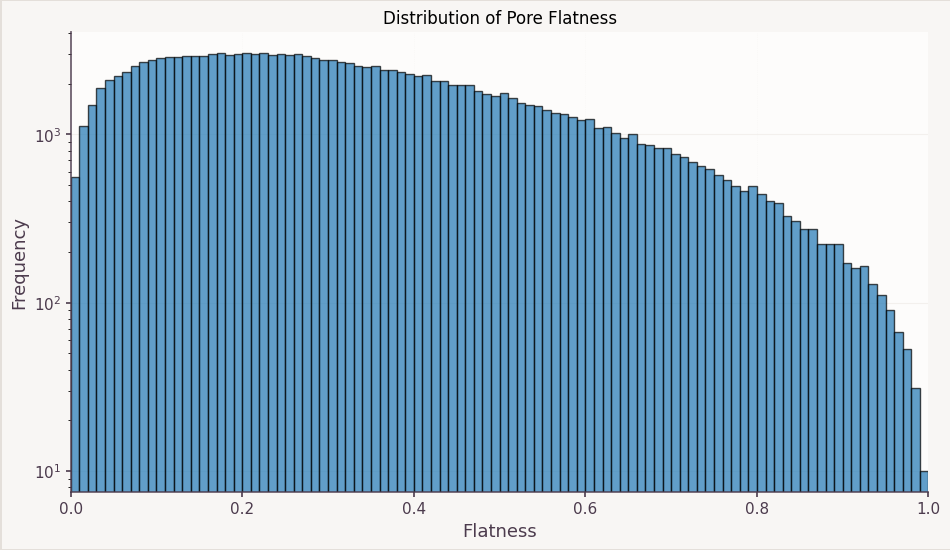

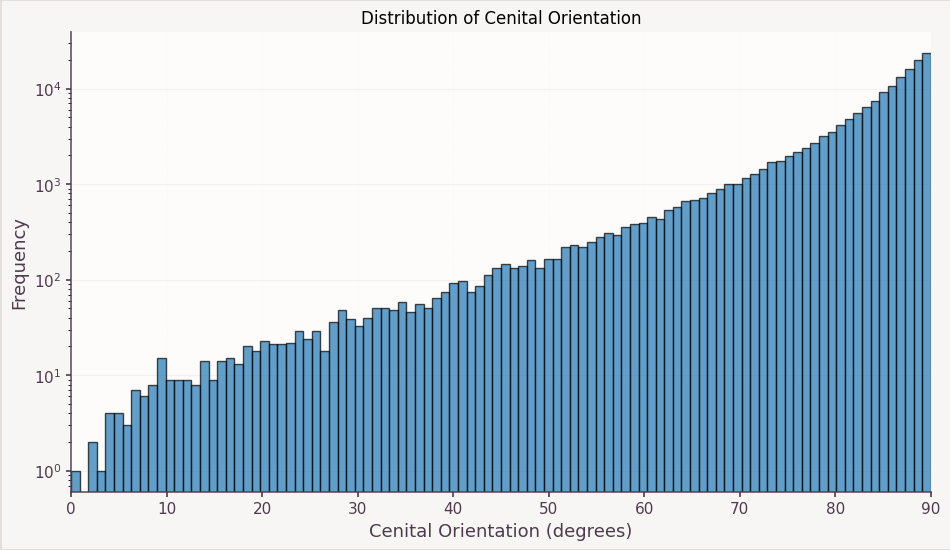

In [19]:
# Flatness histogram (Figure 1)
fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.hist(features_16['flatness'], bins=np.linspace(0, 1, 101), edgecolor='black', alpha=0.7)
ax1.set_xlabel('Flatness')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Pore Flatness')
ax1.set_xlim(0, 1)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
apply_plot_theme()
fig1.savefig(figures_folder / 'pore_flatness_distribution_filtered_16.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Cenital orientation histogram (Figure 2)
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(features_16['cenital_orientation'], bins=np.linspace(0, 90, 101), edgecolor='black', alpha=0.7)
ax2.set_xlabel('Cenital Orientation (degrees)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Cenital Orientation')
ax2.set_xlim(0, 90)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
apply_plot_theme()

fig2.savefig(figures_folder / 'pore_cenital_orientation_distribution_filtered_16.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [20]:
onlypores_volume_final,_,_ = onlypores.onlypores(volume,frontwall=frontwall, backwall=backwall, min_size_filtering=8)

Starting pore detection analysis...
Computing volume bounding box...
Original volume shape: (208, 3405, 1703)
Data bounding box: Z[0:207], Y[0:3404], X[0:1702]
Cropped volume shape: (208, 3405, 1703)
Applying Sauvola adaptive thresholding...
Volume size: 1.12 GB
Available memory: 179.30 GB
Required memory estimate: 2.25 GB
Using parallel implementation...
Window size adjusted to 31 (must be odd)
Applying Sauvola thresholding with parallel processing...
Excluding front wall: slices 0 to 7
Excluding back wall: slices 193 to end
Generating material mask...
Computing material mask using sequential processing...
Filling internal voids...
Material mask generation complete.
Initial pore detection complete. Found 23835959 pore voxels.
Applying pore filtering with minimum size: 8
Cleaning pores with min_size=8...
  Initial connected components: 1415941
  Components after size filtering: 229051
  Valid components after dimensional filtering: 226030
  Components after dimensional filtering: 22603

In [24]:
#label onlypores volume
from skimage import measure
labeled_pores_final = measure.label(onlypores_volume_final, connectivity=3)
print(len(np.unique(labeled_pores_final)))

226031


In [22]:
# Compute features for all labeled pores
features_final = compute_pore_features(labeled_pores_final)

# Display results
print(f"Number of pores analyzed: {len(features_final['label'])}")
print(f"\nFlatness statistics:")
print(f"  Mean: {features_final['flatness'].mean():.4f}")
print(f"  Std: {features_final['flatness'].std():.4f}")
print(f"  Min: {features_final['flatness'].min():.4f}")
print(f"  Max: {features_final['flatness'].max():.4f}")
print(f"\nCenital orientation statistics (degrees):")
print(f"  Mean: {features_final['cenital_orientation'].mean():.2f}")
print(f"  Std: {features_final['cenital_orientation'].std():.2f}")
print(f"  Min: {features_final['cenital_orientation'].min():.2f}")
print(f"  Max: {features_final['cenital_orientation'].max():.2f}")

Number of pores analyzed: 226030

Flatness statistics:
  Mean: 0.3626
  Std: 0.2136
  Min: -0.0000
  Max: 1.0000

Cenital orientation statistics (degrees):
  Mean: 80.54
  Std: 11.12
  Min: 0.00
  Max: 90.00


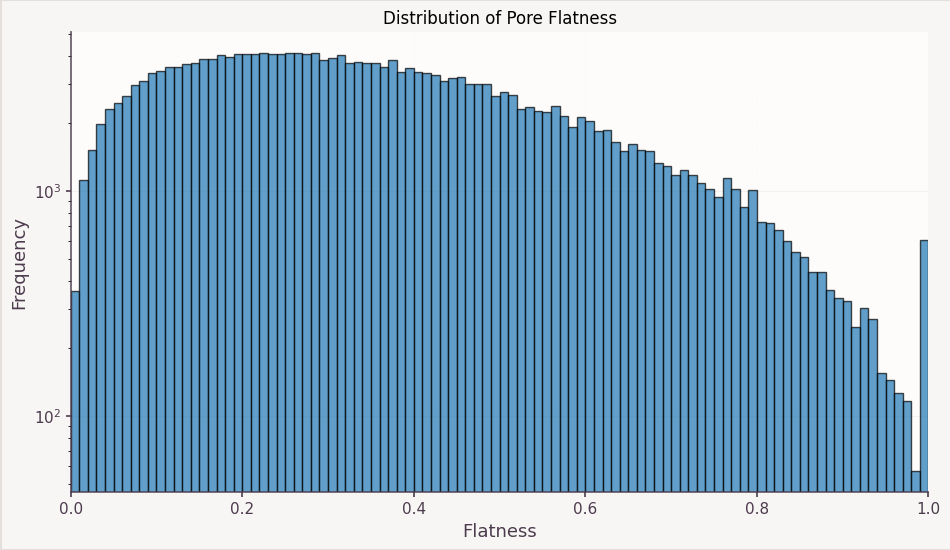

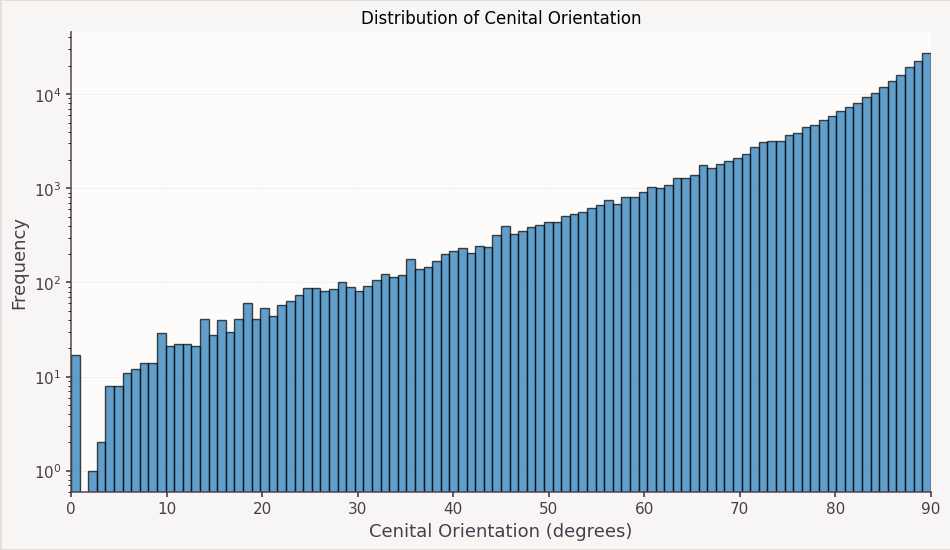

In [23]:
# Flatness histogram (Figure 1)
fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.hist(features_final['flatness'], bins=np.linspace(0, 1, 101), edgecolor='black', alpha=0.7)
ax1.set_xlabel('Flatness')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Pore Flatness')
ax1.set_xlim(0, 1)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
apply_plot_theme()
fig1.savefig(figures_folder / 'pore_flatness_distribution_filtered_final.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Cenital orientation histogram (Figure 2)
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(features_final['cenital_orientation'], bins=np.linspace(0, 90, 101), edgecolor='black', alpha=0.7)
ax2.set_xlabel('Cenital Orientation (degrees)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Cenital Orientation')
ax2.set_xlim(0, 90)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
apply_plot_theme()

fig2.savefig(figures_folder / 'pore_cenital_orientation_distribution_filtered_final.pdf', bbox_inches='tight', dpi=300)
plt.show()